In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv(
    "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Dataset Shape:", df.shape)

print("="*60)
print("MISSING VALUES ANALYSIS")
print("="*60)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Values': missing_values.values
})

print(missing_df)

print("\n" + "="*60)
print("DUPLICATE RECORDS ANALYSIS")
print("="*60)

duplicates = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicates}")

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)

print(df.dtypes)

print("\n" + "="*60)
print("TOTALCHARGES QUALITY CHECK")
print("="*60)

blank_values = (df["TotalCharges"] == " ").sum()

print(f"Blank Values in TotalCharges: {blank_values}")

print("\nSample Values:")
print(df["TotalCharges"].head())

print("\n" + "="*60)
print("UNIQUE VALUES PER COLUMN")
print("="*60)

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

print("\n" + "="*60)
print("NUMERICAL FEATURES SUMMARY")
print("="*60)

print(df.describe())

quality_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Duplicate Rows",
        "Missing Values",
        "Blank Values in TotalCharges"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        (df["TotalCharges"] == " ").sum()
    ]
})

print("\n")
print("="*60)
print("DATA QUALITY SUMMARY")
print("="*60)

print(quality_summary)

Dataset Shape: (7043, 21)
MISSING VALUES ANALYSIS
              Column  Missing Values
0         customerID               0
1             gender               0
2      SeniorCitizen               0
3            Partner               0
4         Dependents               0
5             tenure               0
6       PhoneService               0
7      MultipleLines               0
8    InternetService               0
9     OnlineSecurity               0
10      OnlineBackup               0
11  DeviceProtection               0
12       TechSupport               0
13       StreamingTV               0
14   StreamingMovies               0
15          Contract               0
16  PaperlessBilling               0
17     PaymentMethod               0
18    MonthlyCharges               0
19      TotalCharges               0
20             Churn               0

DUPLICATE RECORDS ANALYSIS
Total Duplicate Rows: 0

DATA TYPES
customerID           object
gender               object
SeniorCitizen   

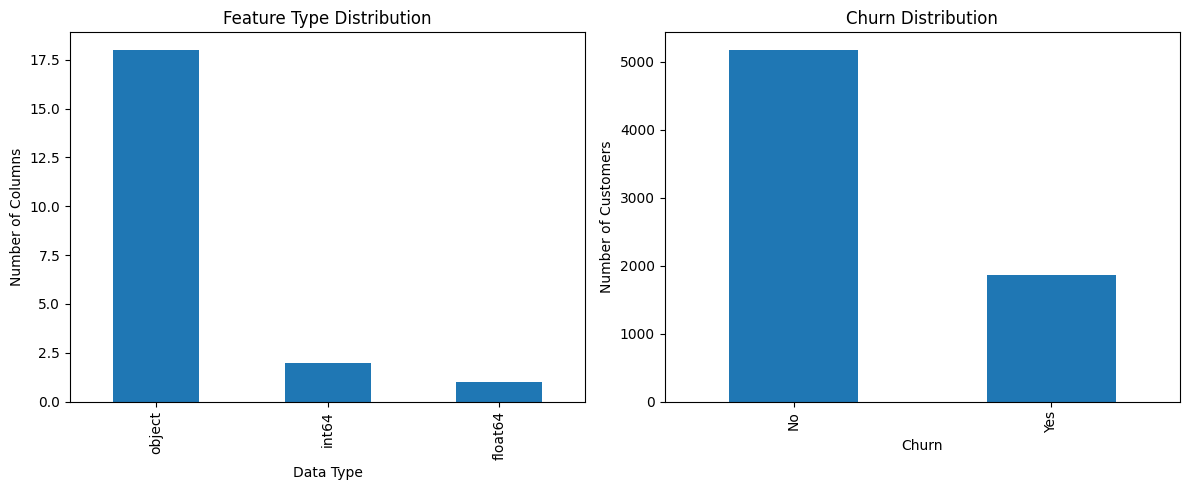

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is already loaded

# 1. Feature type count
type_counts = df.dtypes.value_counts()

# 2. Churn distribution
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(12,5))

# --- Plot 1: Data Type Distribution ---
plt.subplot(1,2,1)
type_counts.plot(kind='bar')
plt.title("Feature Type Distribution")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

# --- Plot 2: Churn Distribution ---
plt.subplot(1,2,2)
churn_counts.plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()